# Exploratory Data Analysis - Customer Churn Prediction

## Objective

The purpose of this exploratory data analysis is to understand customer behavior,
identify patterns associated with churn, and discover factors that may influence
customer retention.

The analysis focuses on:

- Customer churn distribution
    
- Numerical feature patterns
    
- Categorical feature relationships
    
- Feature relationships with churn
    
- Correlation between numerical variables
    
- Business insights that can guide customer retention strategies

In [1]:
## Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings (display all columns when you print a DataFrame.)
pd.set_option("display.max_columns", None) 

# Visualization style (Seaborn will use the whitegrid plotting style for all charts.
sns.set_style("whitegrid")

## Load Cleaned Customer Churn Dataset

The cleaned dataset created during the data cleaning phase will be used for EDA.

In [2]:
df = pd.read_csv("../data/cleaned/churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview
Before analysis, we check the dataset size, data types, and basic statistics.


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [6]:
df.describe(include="number")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Target Variable Analysis

The target variable is **Churn**, which indicates whether a customer left the company.

Understanding churn distribution helps determine:

- The percentage of customers leaving
 
- Whether the dataset is balanced

- The scale of the retention problem

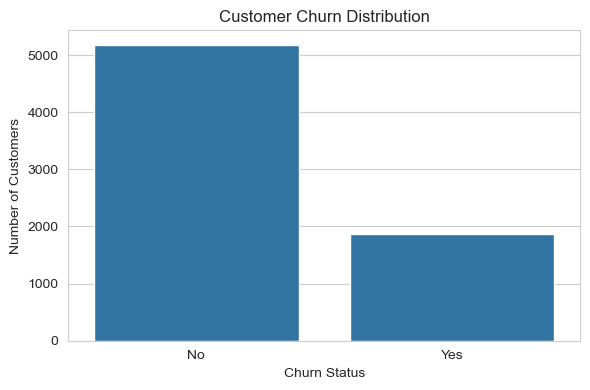

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout() # Adjusts spacing so labels and titles don't overlap.
plt.show()

In [8]:
# Churn Percentage

churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


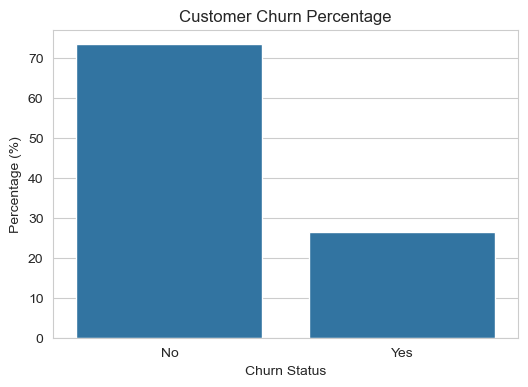

In [9]:
# Visualization

plt.figure(figsize=(6,4))

sns.barplot(
    x=churn_percentage.index,
    y=churn_percentage.values
)

plt.title("Customer Churn Percentage")
plt.ylabel("Percentage (%)")
plt.xlabel("Churn Status")

plt.show()

## Business Insight

The churn distribution shows the percentage of customers who have left the company.

This helps the business understand the current customer retention challenge.
If churn represents a significant proportion of customers, targeted retention
strategies are necessary to reduce revenue loss.

# Numerical Feature Analysis

Numerical variables provide information about customer behavior and spending patterns.

The main variables analyzed are:

- Tenure: How long a customer has stayed with the company

- MonthlyCharges: Monthly subscription cost

- TotalCharges: Total amount paid by the customer

In [10]:
# Tenure Distribution

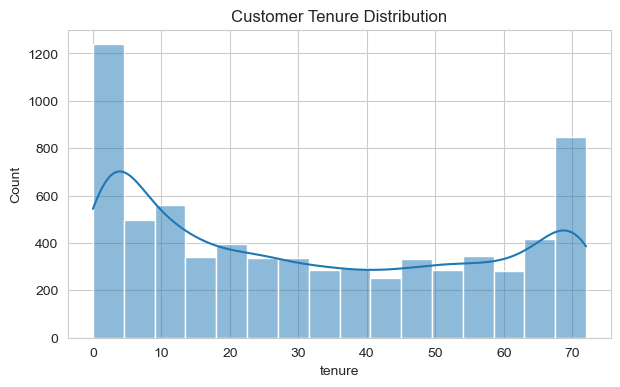

In [11]:
# Histogram

plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="tenure",
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

### Business interpretation

The company continues to acquire new customers while retaining many long-term ones.
Understanding why new customers leave early is important, as early churn can significantly affect revenue.

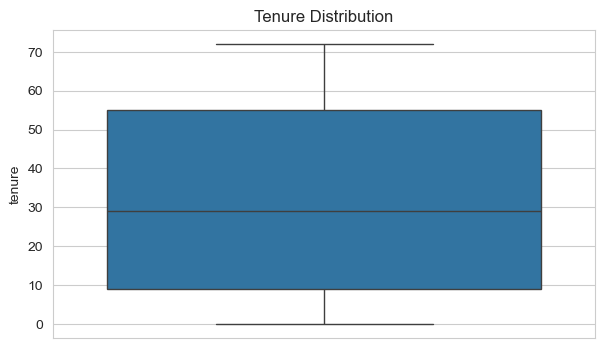

In [12]:
# Boxplot

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    y="tenure"
)

plt.title("Tenure Distribution")

plt.show()

### Business interpretation

Since there are no extreme tenure values, the variable appears clean and does not require outlier treatment.
Tenure is likely to be an important predictor of churn because customer loyalty often increases with time.

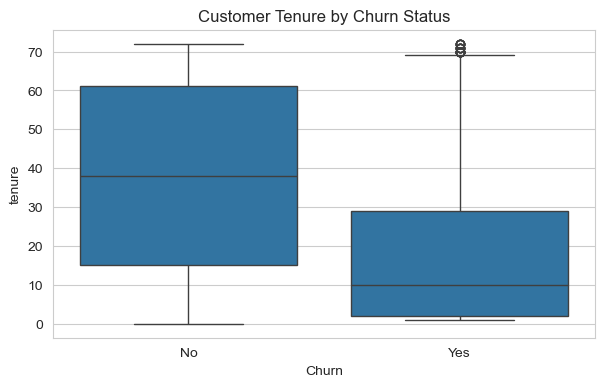

In [13]:
# compares the tenure of customers who churned versus those who stayed.

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.show()

### Business insight

Customers with shorter tenures are considerably more likely to churn than long-term customers. This suggests that customer retention efforts should focus on improving the experience during the first few months of service, when the risk of churn is highest.

Business Insight

Customers appear to cluster into new and long-term groups, suggesting different stages of the customer lifecycle.
**Since tenure reflects customer loyalty**, it is expected to play a significant role in predicting churn.

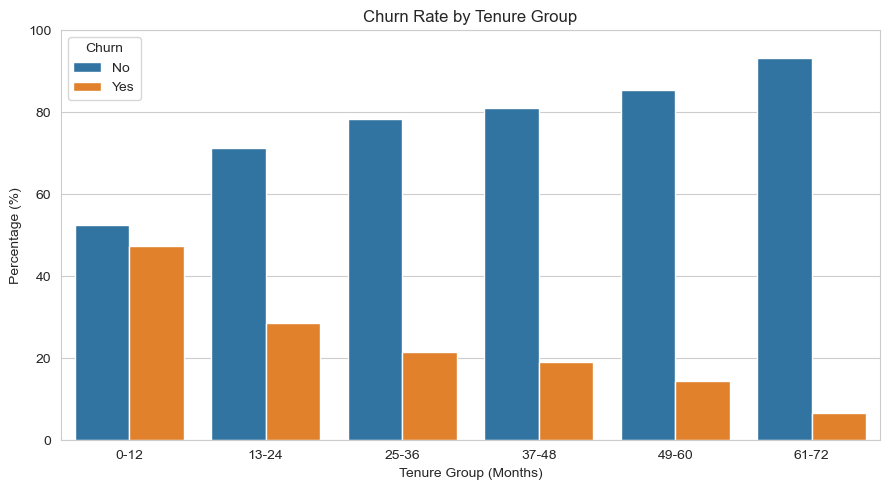

In [14]:
# Churn Rate by Tenure Groups

bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]

df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

churn_rate = (
    df.groupby("TenureGroup", observed=False)["Churn"]
      .value_counts(normalize=True)
      .rename("Percentage")
      .mul(100)
      .reset_index()
)

# Visualize

plt.figure(figsize=(9, 5))

sns.barplot(
    data=churn_rate,
    x="TenureGroup",
    y="Percentage",
    hue="Churn"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Business insight

This visualization helps identify when customers are at the greatest risk of churning. **Most churn occurs within the first year**, the company should prioritize customer onboarding, early engagement, and proactive retention campaigns during the first 12 months. Long-tenure customers are valuable assets and should be rewarded with loyalty programs to maintain their retention.

#### Tenure vs Monthly Charges

Question answered

Are long-term customers paying more or less each month?

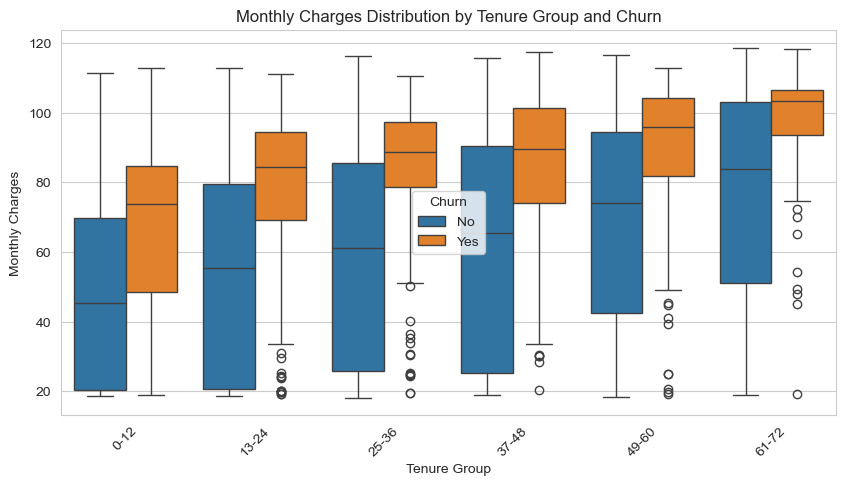

In [15]:
# Monthly Charges Distribution by Tenure Group 


plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="TenureGroup",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges Distribution by Tenure Group and Churn")
plt.xlabel("Tenure Group")
plt.ylabel("Monthly Charges")

plt.xticks(rotation=45)
plt.show()

### Business insight

- Customers with high monthly charges in early tenure groups have higher churn.

- Customers paying expensive plans may leave if they don't see enough value.

- Long-term customers with high charges are likely more satisfied.

Overall: **High monthly charges + short tenure = high churn risk**

#### Tenure by Contract Type

Question answered:

Which contract types keep customers longer?

<Axes: xlabel='Contract', ylabel='tenure'>

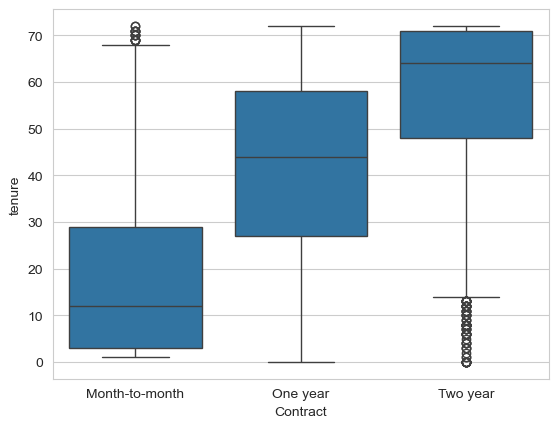

In [16]:
sns.boxplot(
    data=df,
    x="Contract",
    y="tenure"
)


Month-to-month customers usually have the shortest tenure.
Two-year contracts typically have the longest tenure.

### Tenure by Internet Service
Question answered

Do customers with different internet services stay for different lengths of time?

<Axes: xlabel='InternetService', ylabel='tenure'>

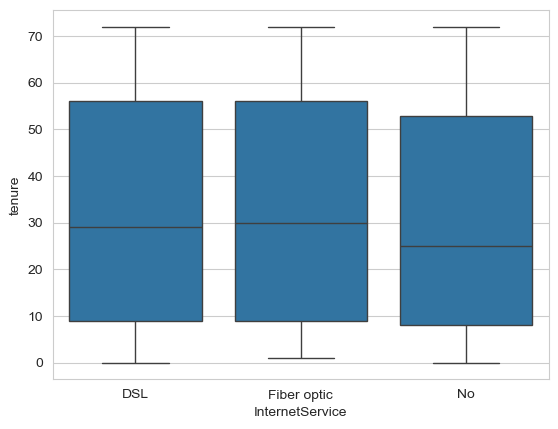

In [17]:
sns.boxplot(
    data=df,
    x="InternetService",
    y="tenure"
)

### Tenure by Payment Method

This can reveal whether certain payment methods are associated with longer customer relationships.

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

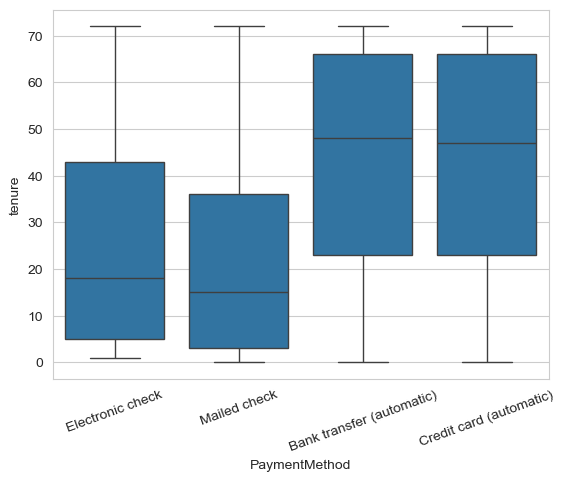

In [18]:
sns.boxplot(
    data=df,
    x="PaymentMethod",
    y="tenure"
)

plt.xticks(rotation=20)

Bank transfer and Credit card payment methods are associated with longer customer relationships.

### MonthlyCharges Distribution

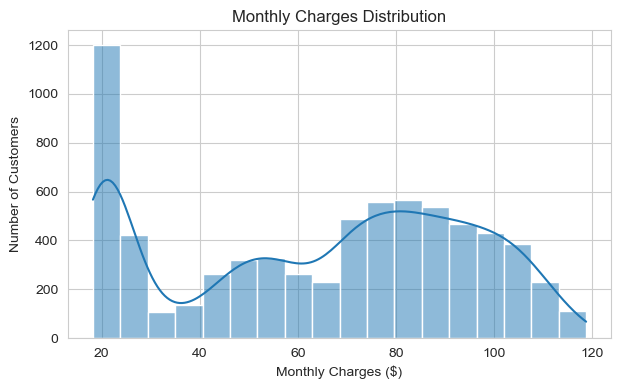

In [19]:
# Histogram
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

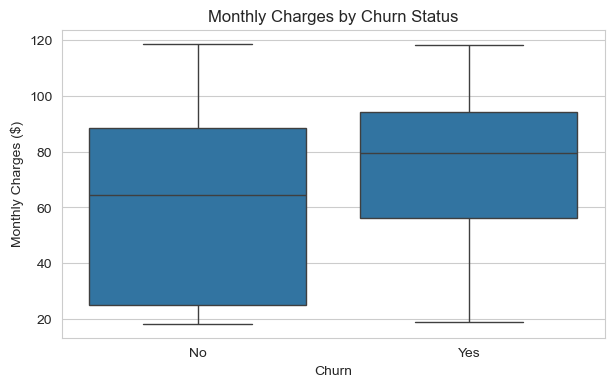

In [20]:
# compare charges against churn:

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

The boxplot shows that customers who churn generally have higher monthly charges 

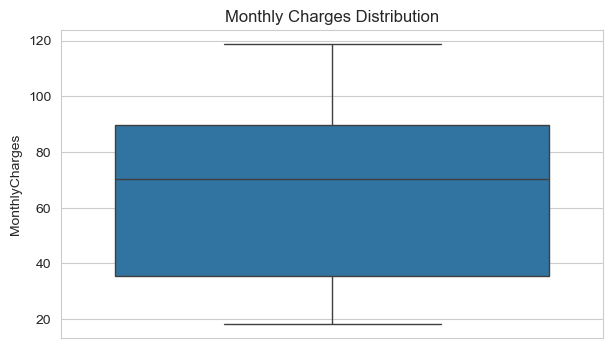

In [21]:
# Boxplot

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution")

plt.show()

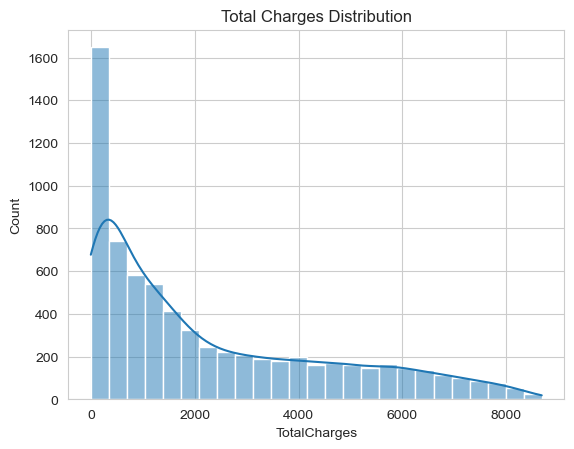

In [22]:
# plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True
)

plt.title("Total Charges Distribution")
plt.show()

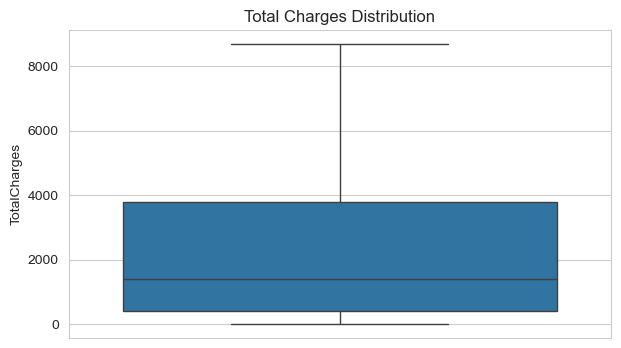

In [23]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    y="TotalCharges"
)

plt.title("Total Charges Distribution")

plt.show()

Business Insight

The numerical distributions reveal customer spending behavior.

Customers with shorter tenure and lower total charges may represent newer customers, who could require early engagement strategies to prevent churn.

# Categorical Feature Analysis

Categorical variables help identify customer groups with higher churn risk.

We analyze:

- Gender
- Contract
- Internet Service
- Payment Method
- Partner
- Dependents
- Senior Citizen status

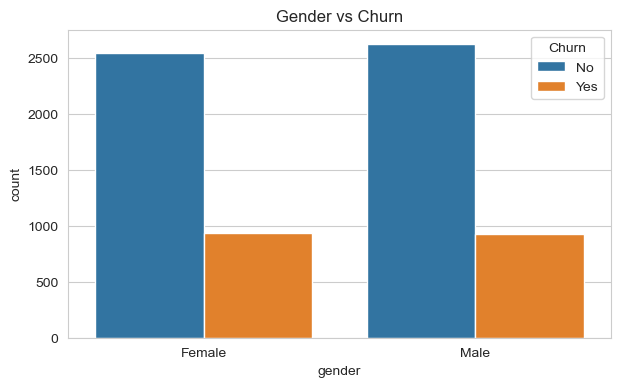

In [24]:
# Gender vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

Text(0.5, 1.0, 'Contract Type vs Churn')

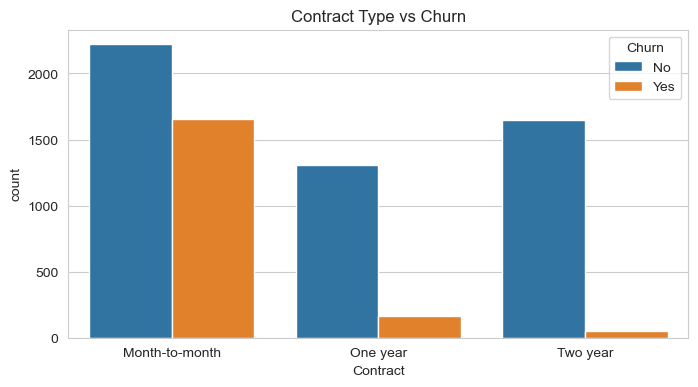

In [25]:
# Contract vs Churn

plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

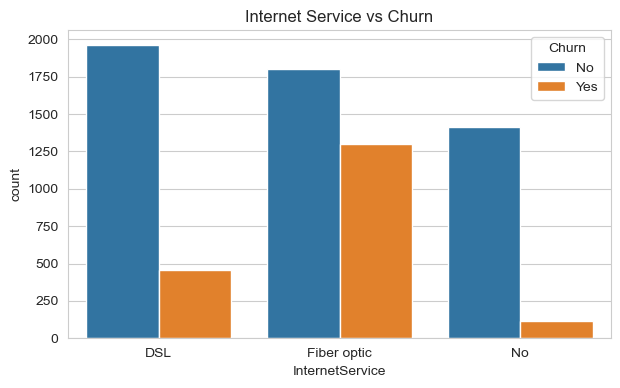

In [26]:
# InternetService vs Churn

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

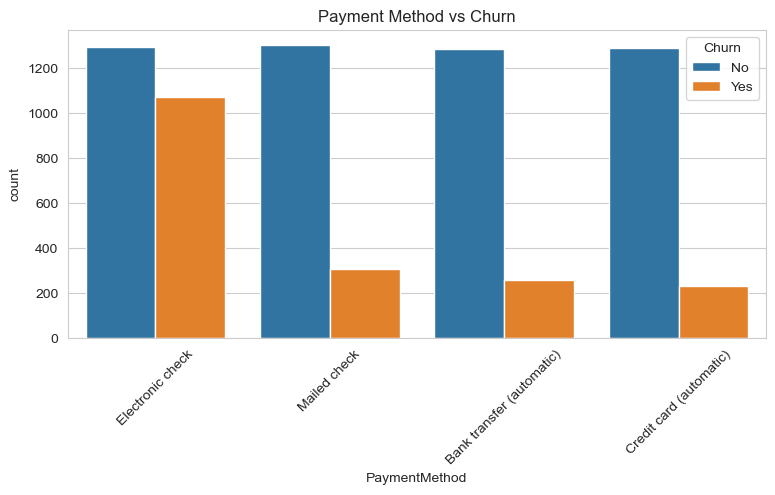

In [27]:
# PaymentMethod vs Churn

plt.figure(figsize=(9,4))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

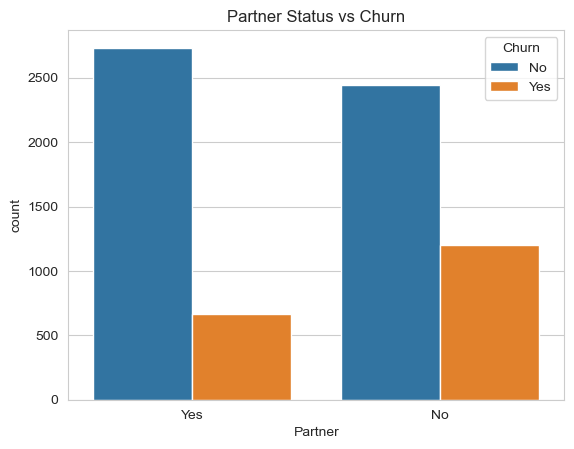

In [28]:
# Partner vs Churn

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Partner Status vs Churn")

plt.show()

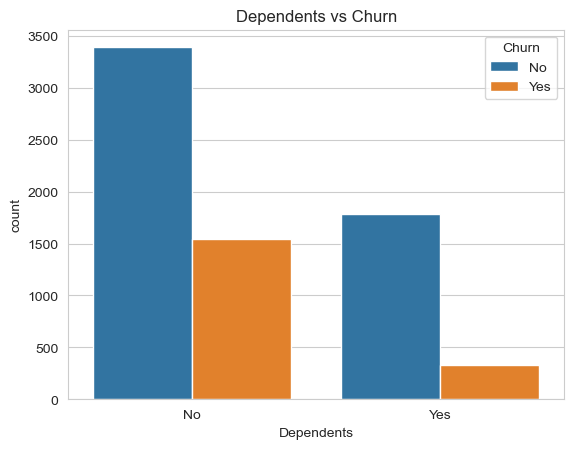

In [29]:
# Dependents vs Churn
sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Dependents vs Churn")

plt.show()

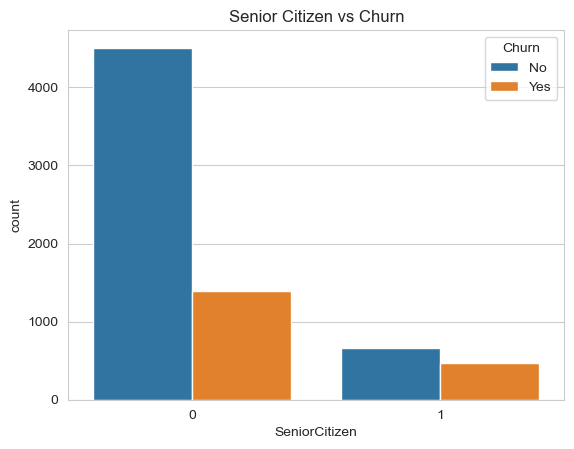

In [30]:
# SeniorCitizen vs Churn

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

## Business Insight

This visualization highlights the differences in churn behavior across various customer segments.

The analysis shows that customers who are **not senior citizens, have no dependents, do not have a partner, use electronic payment methods, subscribe to fiber optic internet services, and have month-to-month contracts** show higher churn tendencies. These customer groups represent potential high-risk segments that can be prioritized for retention strategies such as personalized offers, loyalty incentives, proactive customer support, and improved service experiences.

# Numerical Features vs Churn

This section investigates whether numerical variables differ between customers
who stayed and customers who churned.

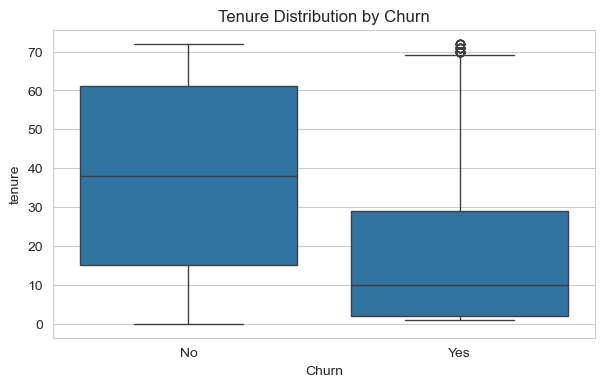

In [31]:
# Tenure by Churn

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")

plt.show()

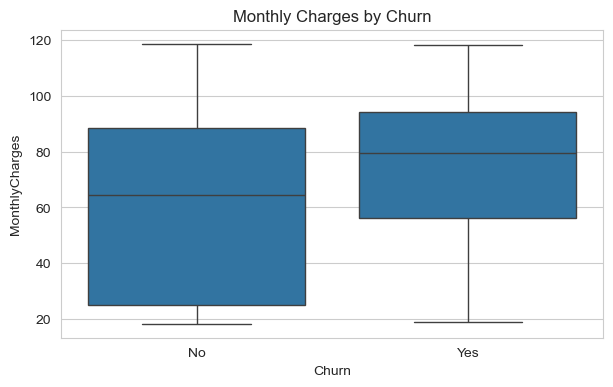

In [32]:
# MonthlyCharges by Churn

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")

plt.show()

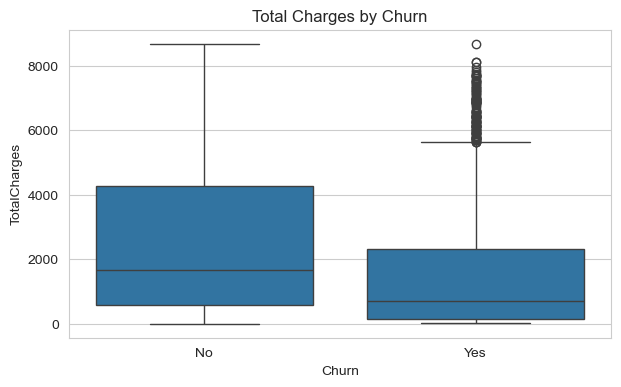

In [33]:
# TotalCharges by Churn

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")

plt.show()

Customers who churn generally have lower total charges than customers who stay. This suggests many customers leave before accumulating large lifetime spending, likely because they cancel their service relatively early. In contrast, retained customers tend to stay longer, resulting in higher cumulative charges and greater variability in total spending.

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

Strong correlations may reveal:

- Similar information between features
    
- Potential multicollinearity
    
- Important variables for modeling

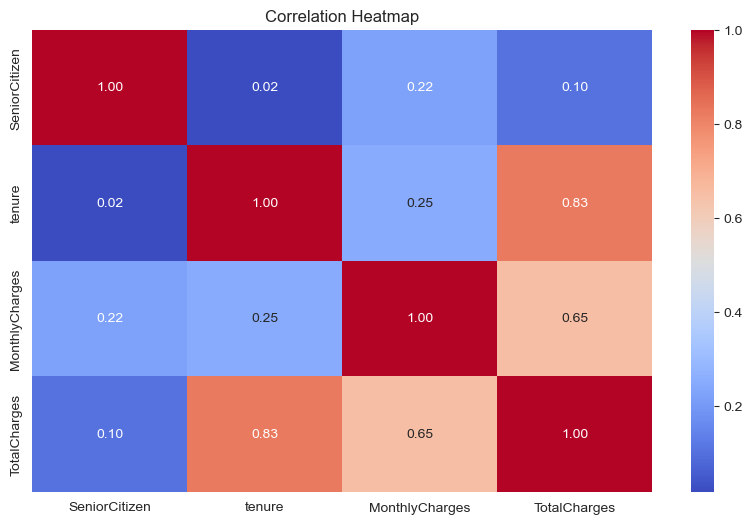

In [34]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

The strong correlation between tenure and TotalCharges is expected because customers who have been with the company longer accumulate higher total charges. Since these variables provide similar information, using both in a regression-based model may introduce multicollinearity. In such cases, it is good practice to evaluate the Variance Inflation Factor (VIF) or consider removing one of the variables if multicollinearity negatively affects model performance.

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the numerical features, use only the predictor variables.

X = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]]

# Calculate the VIF
vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])]
vif

# Sort the results
vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
3,TotalCharges,8.080935
1,tenure,6.332627
2,MonthlyCharges,3.694794
0,SeniorCitizen,1.257276


### Multicollinearity Analysis (VIF)

Variance Inflation Factor (VIF) was calculated to identify highly correlated numerical predictors.

The results show moderate multicollinearity between **TotalCharges and tenure**, with VIF values of 8.08 and 6.33 respectively. This relationship is expected because total customer charges increase as customer tenure increases.

However, since the VIF values remain below the critical threshold of 10, the variables were retained for initial modeling. Feature selection will be evaluated during model development by comparing model performance with and without highly correlated features.

# Final Business Insights

## Key Findings

1. Customer churn appears to be associated with factors such as customer tenure, pricing levels, and the type of services subscribed to.

2. Customers who have recently joined the company are more likely to churn, highlighting the importance of effective onboarding processes      and early customer engagement.

3. Contract type plays an important role in customer retention, with customers on short-term contracts showing greater churn risk compare      to those on longer-term agreements.

4. Specific customer characteristics, payment methods, and service combinations are linked with higher churn rates, helping identify           segments that require closer attention.

5. Customers who are non-senior citizens, do not have dependents or partners, use electronic payment methods, subscribe to fiber optic         internet services, and have month-to-month contracts demonstrate higher likelihoods of churn.

6. Customers with shorter tenure and lower total spending may represent newer customers who have not yet developed strong loyalty to the       company, making early intervention is important for improving retention.

## Business Recommendations

- Develop customer onboarding programs that provide support and engagement during the early stages of the customer relationship.

- Encourage customers to adopt longer-term contracts by introducing loyalty benefits, incentives, or flexible subscription plans.

- Use predictive models to identify customers who are at higher risk of leaving and allow proactive retention actions.

- Create personalized retention strategies based on customer characteristics, service usage, and payment behavior.

- Improve customer experience for high-risk segments through targeted offers, proactive communication, and enhanced support services.